# 🎧 Audio Feature Extraction & Classification Lab

**Objective:** Extract features from two classes of audio (e.g., with and without bird sounds), visualize the differences, and train simple classifiers to separate them.

---

## 1. Introduction

We will:
- Load and play two audio files (one with bird sound, one without)
- Extract time, frequency, and time-frequency domain features
- Train a simple classifier to distinguish them


**FOR EACH FIGURE PLOT TOGETHER THE TWO PLOTS FOR COMPARISON**

### 🔹 Import Libraries

In [3]:
import librosa
import librosa.display
import IPython.display as ipd
import numpy as np
import matplotlib.pyplot as plt
import os

### 🔹 Mount google drive

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### 🔹 Load and Play Audio Files

In [5]:
bird_path = "/content/drive/MyDrive/ff1010bird/19037.wav"
no_bird_path = "/content/drive/MyDrive/ff1010bird/195597.wav"

y_bird, sr_bird = librosa.load(bird_path)
y_no_bird, sr_no_bird = librosa.load(no_bird_path)

ipd.display(ipd.Audio(y_bird, rate=sr_bird))
ipd.display(ipd.Audio(y_no_bird, rate=sr_no_bird))

## 2. Exploration

**Check shape:**

In [6]:
print("Bird audio shape:", y_bird.shape)
print("No-bird audio shape:", y_no_bird.shape)

Bird audio shape: (220500,)
No-bird audio shape: (220500,)


**Check duration:**

In [7]:
print("Bird audio duration:", len(y_bird)/sr_bird, "seconds")
print("No-bird audio duration:", len(y_no_bird)/sr_no_bird, "seconds")

Bird audio duration: 10.0 seconds
No-bird audio duration: 10.0 seconds


**Check sample rate (sampling frequency)**

In [8]:
print("Bird sample rate:", sr_bird, "Hz")
print("No-bird sample rate:", sr_no_bird, "Hz")

Bird sample rate: 22050 Hz
No-bird sample rate: 22050 Hz


### 🔹 Visualize the Waveforms

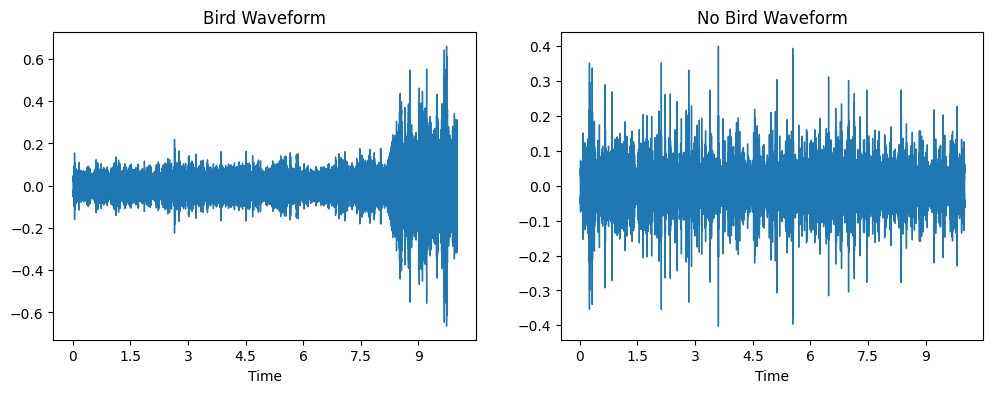

In [9]:
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
librosa.display.waveshow(y_bird, sr=sr_bird)
plt.title("Bird Waveform")
plt.subplot(1, 2, 2)
librosa.display.waveshow(y_no_bird, sr=sr_no_bird)
plt.title("No Bird Waveform")
plt.show()

   **Preprocessing**
   
    - Trim silence
    - Normalize amplitude
    - Resample

In [10]:
def preprocess_audio(file_path, target_sr=22050):
    # Load audio file
    y, sr = librosa.load(file_path, sr=None)
    # Trim silence from beginning and end
    y, _ = librosa.effects.trim(y)
    # Normalize amplitude
    y = librosa.util.normalize(y)
    # Resample to target sample rate
    if sr != target_sr:
        y = librosa.resample(y, orig_sr=sr, target_sr=target_sr)
        sr = target_sr
    return y, sr

y_no_bird, sr_no_bird= preprocess_audio(no_bird_path)
y_bird, sr_bird = preprocess_audio(bird_path)

## 3. Time Domain Features
Extract and compare the following:
- Amplitude Envelope
- RMS Energy
- Zero Crossing Rate

In [11]:
FRAME_SIZE = 1024 # This is the frame size/length to use for all the audio processing
HOP_LENGTH = 512  # This is the hop size/length to use for all the audio processing

### For both audio show the amplitude

In [12]:
frames_bird = librosa.util.frame(y_bird, frame_length=FRAME_SIZE, hop_length=HOP_LENGTH)
AE_bird = np.max(np.abs(frames_bird), axis=0)

frames_nobird = librosa.util.frame(y_no_bird, frame_length=FRAME_SIZE, hop_length=HOP_LENGTH)
AE_nobird = np.max(np.abs(frames_nobird), axis=0)

t_bird = librosa.frames_to_time(np.arange(AE_bird.shape[0]), sr=sr_bird, hop_length=HOP_LENGTH)
t_no_bird = librosa.frames_to_time(np.arange(AE_nobird.shape[0]), sr=sr_no_bird, hop_length=HOP_LENGTH)

t_bird_full = np.linspace(0, len(y_bird) / sr_bird, num=len(y_bird))
t_no_full = np.linspace(0, len(y_no_bird) / sr_no_bird, num=len(y_no_bird))

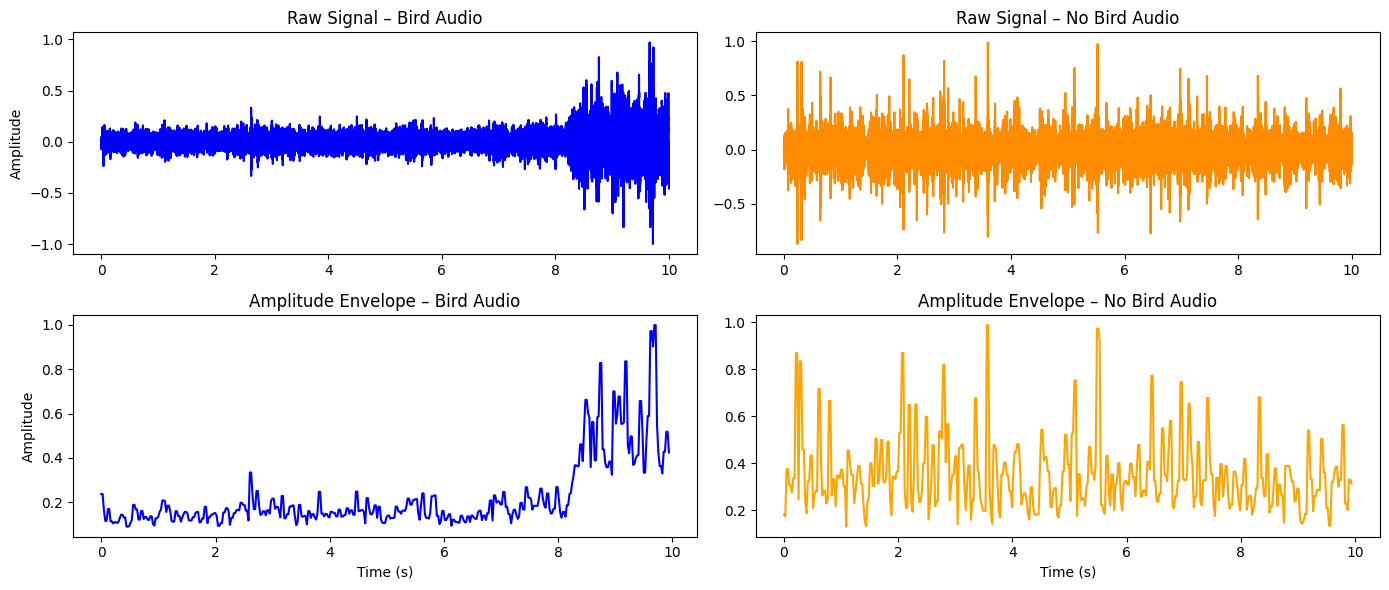

In [13]:
plt.figure(figsize=(14, 6))

# Bird signal
plt.subplot(2, 2, 1)
plt.plot(t_bird_full, y_bird, color='blue')
plt.title("Raw Signal – Bird Audio")
plt.ylabel("Amplitude")

plt.subplot(2, 2, 3)
plt.plot(t_bird, AE_bird, color='blue')
plt.title("Amplitude Envelope – Bird Audio")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")

# No-bird signal
plt.subplot(2, 2, 2)
plt.plot(t_no_full, y_no_bird, color='darkorange')
plt.title("Raw Signal – No Bird Audio")

plt.subplot(2, 2, 4)
plt.plot(t_no_bird, AE_nobird, color='orange')
plt.title("Amplitude Envelope – No Bird Audio")
plt.xlabel("Time (s)")

plt.tight_layout()
plt.show()

### Use the "librosa.feature.rms" function to extract the rms of all audio files

In [14]:
rms_bird = librosa.feature.rms(y=y_bird, frame_length=FRAME_SIZE, hop_length=HOP_LENGTH)[0]
rms_nobird= librosa.feature.rms(y=y_no_bird, frame_length=FRAME_SIZE, hop_length=HOP_LENGTH)[0]

### Create the time vectors for the rms plots using the "librosa.display.waveshow" function

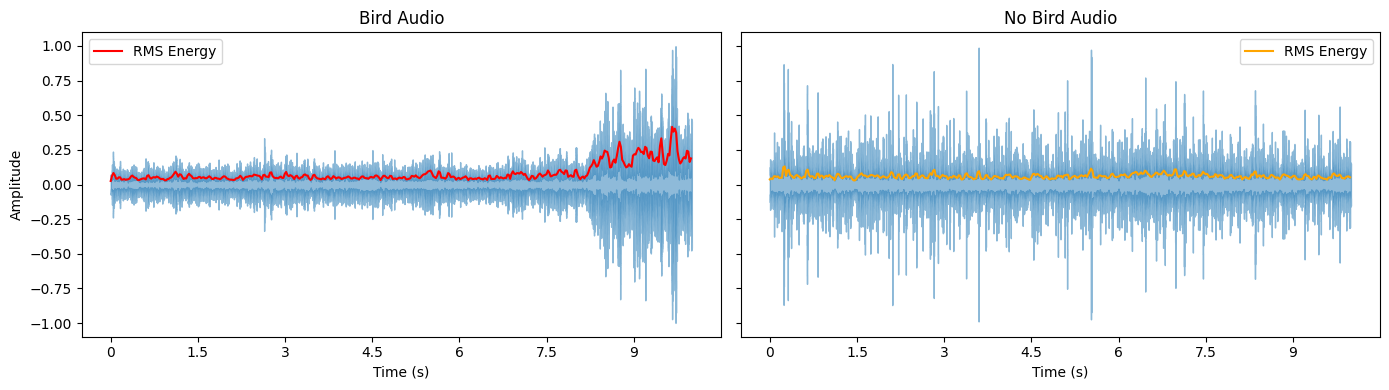

In [15]:
frames = range(len(rms_bird))
t_vector = librosa.frames_to_time(frames, sr=sr_bird, hop_length=HOP_LENGTH)

fig, axs = plt.subplots(1, 2, figsize=(14, 4), sharey=True)

# Bird audio
librosa.display.waveshow(y_bird, sr=sr_bird, alpha=0.5, ax=axs[0])
axs[0].plot(t_vector, rms_bird, color='r', label='RMS Energy')
axs[0].set_title("Bird Audio")
axs[0].set_xlabel("Time (s)")
axs[0].set_ylabel("Amplitude")
axs[0].legend()

# No bird audio
librosa.display.waveshow(y_no_bird, sr=sr_no_bird, alpha=0.5, ax=axs[1])
axs[1].plot(t_vector, rms_nobird, color='orange', label='RMS Energy')
axs[1].set_title("No Bird Audio")
axs[1].set_xlabel("Time (s)")
axs[1].legend()

plt.tight_layout()
plt.show()

### Use the "librosa.feature.zcr" function to extract the zero crossing rate of all audio files

In [16]:
zcr_bird = librosa.feature.zero_crossing_rate(y_bird, hop_length=HOP_LENGTH)[0]
zcr_nobird = librosa.feature.zero_crossing_rate(y_no_bird, hop_length=HOP_LENGTH)[0]


### represent the ZCR of all the audios

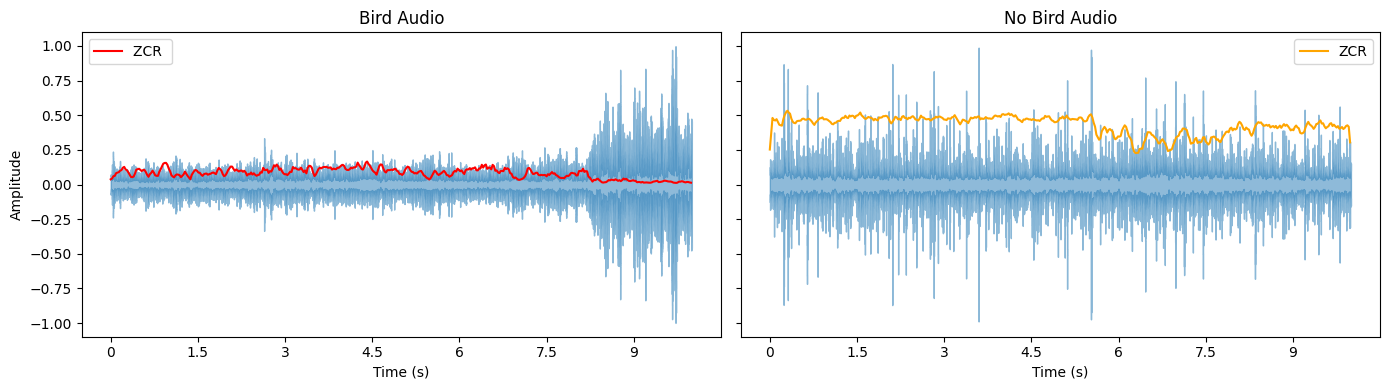

In [17]:
fig, axs = plt.subplots(1, 2, figsize=(14, 4), sharey=True)

# Bird audio
librosa.display.waveshow(y_bird, sr=sr_bird, alpha=0.5, ax=axs[0])
axs[0].plot(t_vector, zcr_bird, color='r', label='ZCR ')
axs[0].set_title("Bird Audio")
axs[0].set_xlabel("Time (s)")
axs[0].set_ylabel("Amplitude")
axs[0].legend()

# No bird audio
librosa.display.waveshow(y_no_bird, sr=sr_no_bird, alpha=0.5, ax=axs[1])
axs[1].plot(t_vector, zcr_nobird, color='orange', label='ZCR')
axs[1].set_title("No Bird Audio")
axs[1].set_xlabel("Time (s)")
axs[1].legend()

plt.tight_layout()
plt.show()

## 4. Frequency Domain Features
- Spectral Centroid
- Spectral Bandwidth
- Spectral flux
- FFT

4.1 Spectral Centroid:

- Use the "librosa.feature.spectral_centroid" function to extract the spectral centroid
- Plot the spectral centroid across frames, remember to use the time vectors

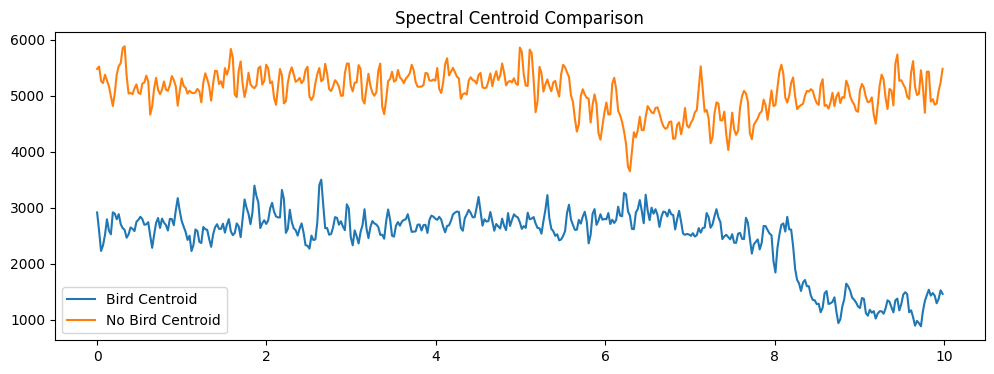

In [18]:
centroid_bird = librosa.feature.spectral_centroid(y=y_bird, sr=sr_bird)[0]
centroid_no = librosa.feature.spectral_centroid(y=y_no_bird, sr=sr_no_bird)[0]

plt.figure(figsize=(12, 4))
plt.plot(t_vector,centroid_bird, label='Bird Centroid')
plt.plot(t_vector,centroid_no, label='No Bird Centroid')
plt.legend()
plt.title('Spectral Centroid Comparison')
plt.show()

4.2 Spectral spread:

- Use the "librosa.feature.spectral_bandwidth" function to extract the spectral spread
- Plot the spectral spread across frames, remember to use the time vectors

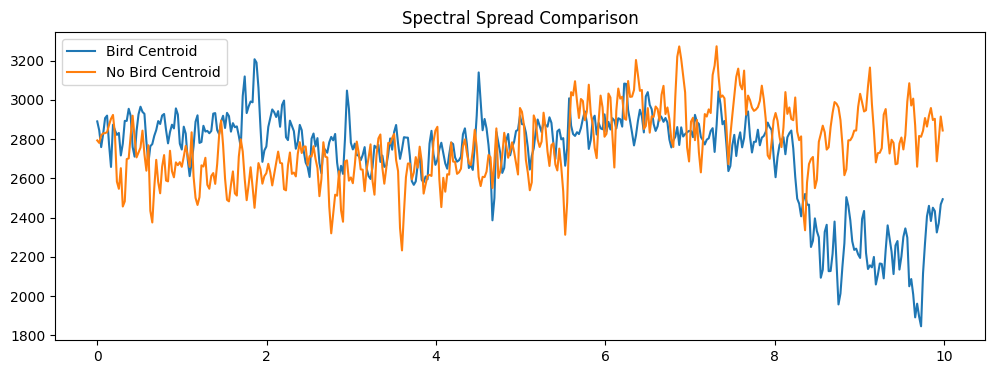

In [19]:
spread_bird = librosa.feature.spectral_bandwidth(y=y_bird, sr=sr_bird)[0]
spread_no = librosa.feature.spectral_bandwidth(y=y_no_bird, sr=sr_no_bird)[0]

plt.figure(figsize=(12, 4))
plt.plot(t_vector,spread_bird, label='Bird Centroid')
plt.plot(t_vector,spread_no, label='No Bird Centroid')
plt.legend()
plt.title('Spectral Spread Comparison')
plt.show()

4.3 Spectral Flux:

- Use the "librosa.onset.onset_strength" function to extract the spectral flux
- Plot the spectral flux across frames, remember to use the time vectors

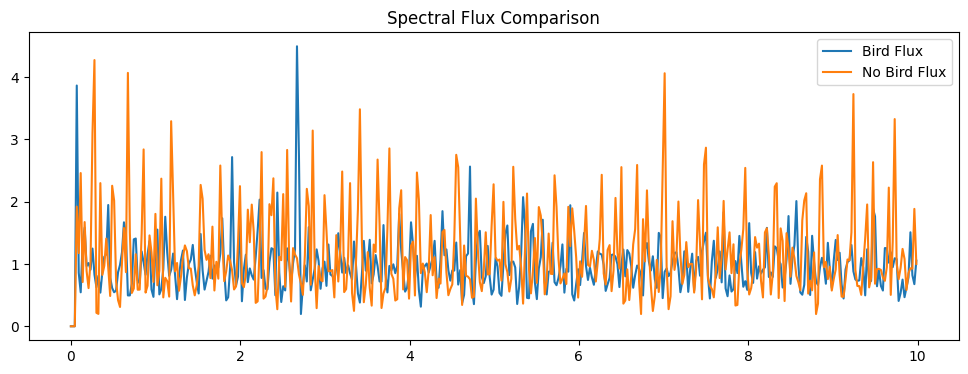

In [20]:
flx_bird = librosa.onset.onset_strength(y=y_bird, sr=sr_bird)
flx_no = librosa.onset.onset_strength(y=y_no_bird, sr=sr_no_bird)

plt.figure(figsize=(12, 4))
plt.plot(t_vector,flx_bird, label='Bird Flux')
plt.plot(t_vector,flx_no, label='No Bird Flux')
plt.legend()
plt.title('Spectral Flux Comparison')
plt.show()

4.4 FFT:

- Calculate the FFT of the audio signals using the "np.fft.fft" function
- Calculate the magnitude of the fft using "np.abs" function
- Plot the magnitude spectrum, remember to use the frequency vector

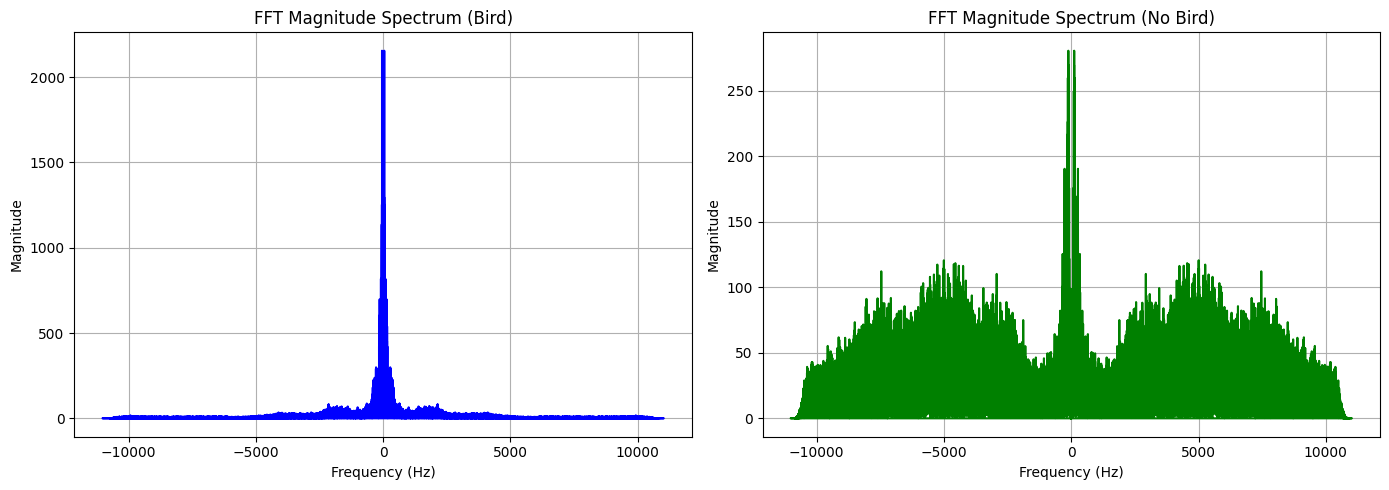

In [21]:
# FFT
fft_bird = np.fft.fft(y_bird)
fft_no_bird = np.fft.fft(y_no_bird)

# Magnitude Spectrum
mag_bird = np.abs(fft_bird)
mag_nobird = np.abs(fft_no_bird)

# Frequency vector (in Hz)
freqs_bird = np.fft.fftfreq(len(mag_bird), d=1/sr_bird)
freqs_no = np.fft.fftfreq(len(mag_nobird), d=1/sr_no_bird)

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(freqs_bird, mag_bird, color='blue')
plt.title('FFT Magnitude Spectrum (Bird)')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Magnitude')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(freqs_no, mag_nobird, color='green')
plt.title('FFT Magnitude Spectrum (No Bird)')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Magnitude')
plt.grid(True)

plt.tight_layout()
plt.show()

## 5. Time-Frequency Features:

- Spectrogram
- Log-amplitude spectrogram
- Log-log spectrogram
- Log Mel Spectrogram
- MCFF

5.1 Spectrogram:

- Calculate the STFT of the audio signals using "librosa.stft" function
- Convert STFT to Spectrogram. This is the square of the absolute.
- Plot the Spectrogram with linear on both frequency and time axes

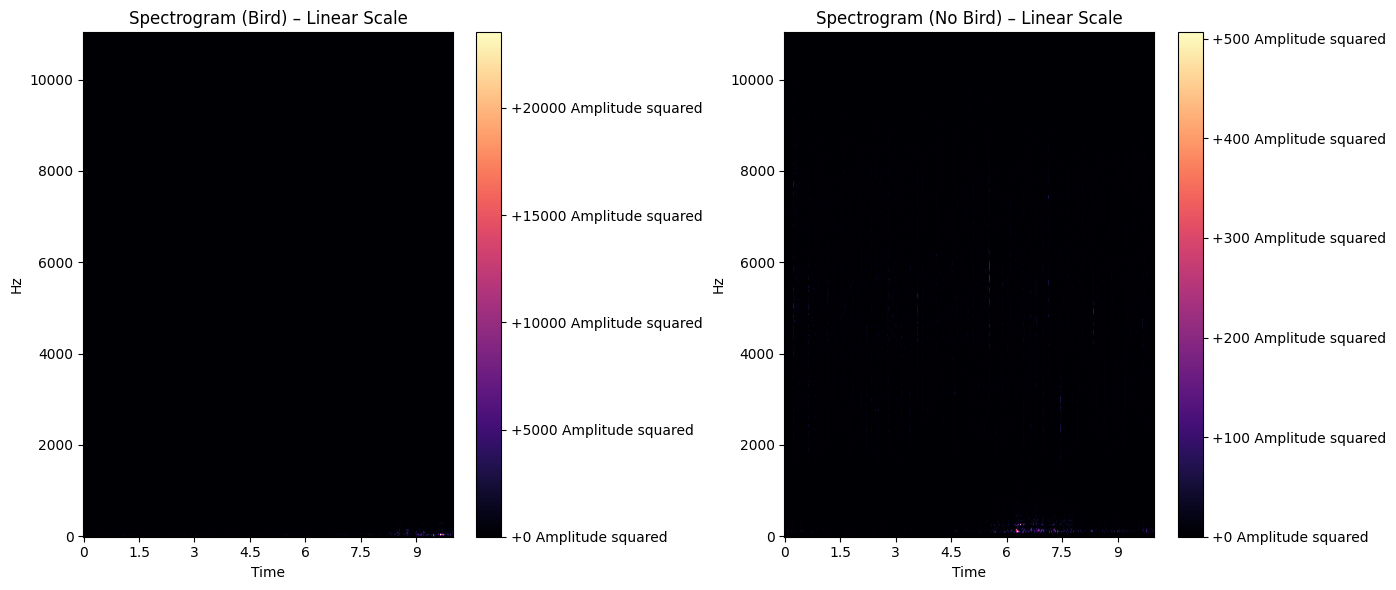

In [22]:
# STFT
stft_bird = librosa.stft(y_bird, n_fft=1024, hop_length=HOP_LENGTH)
stft_no_bird = librosa.stft(y_no_bird, n_fft=1024, hop_length=HOP_LENGTH)

# Convert to Spectrogram
spec_bird = np.abs(stft_bird)**2
spec_no_bird = np.abs(stft_no_bird)**2

plt.figure(figsize=(14, 6))

# Bird Spectrogram
plt.subplot(1, 2, 1)
librosa.display.specshow(spec_bird, sr=sr_bird, hop_length=512, x_axis='time', y_axis='linear')
plt.colorbar(format="%+2.0f Amplitude squared")
plt.title("Spectrogram (Bird) – Linear Scale")

# No Bird Spectrogram
plt.subplot(1, 2, 2)
librosa.display.specshow(spec_no_bird, sr=sr_no_bird, hop_length=512, x_axis='time', y_axis='linear')
plt.colorbar(format="%+2.0f Amplitude squared")
plt.title("Spectrogram (No Bird) – Linear Scale")

plt.tight_layout()
plt.show()

5.2 Log amplitude Spectrogram:

- Compute and plot the log-amplitude spectrogram, use the "librosa.power_to_db" function

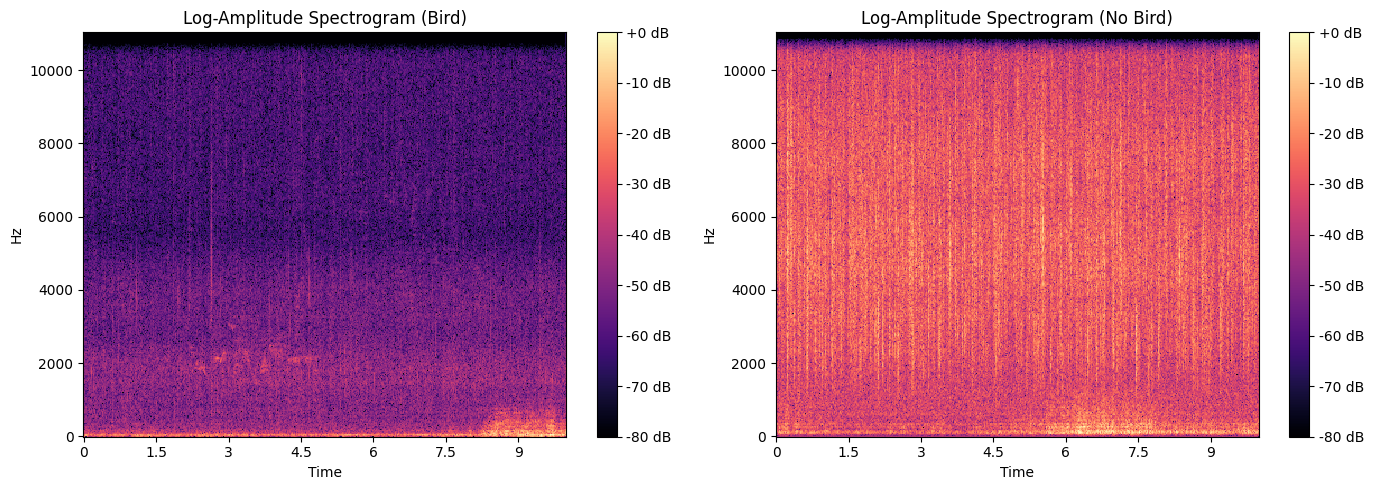

In [23]:
# Convert to dB (log scale)
S_db_bird = librosa.power_to_db(spec_bird, ref=np.max)
S_db_no_bird = librosa.power_to_db(spec_no_bird, ref=np.max)

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
librosa.display.specshow(S_db_bird, sr=sr_bird, x_axis='time', y_axis='linear')
plt.colorbar(format='%+2.0f dB')
plt.title('Log-Amplitude Spectrogram (Bird)')

plt.subplot(1, 2, 2)
librosa.display.specshow(S_db_no_bird, sr=sr_no_bird, x_axis='time', y_axis='linear')
plt.colorbar(format='%+2.0f dB')
plt.title('Log-Amplitude Spectrogram (No Bird)')

plt.tight_layout()
plt.show()

5.3 Log-log Spectrogram:

- Compute and plot the log-log spectrogram, pass a log argument to the y-axis parameter

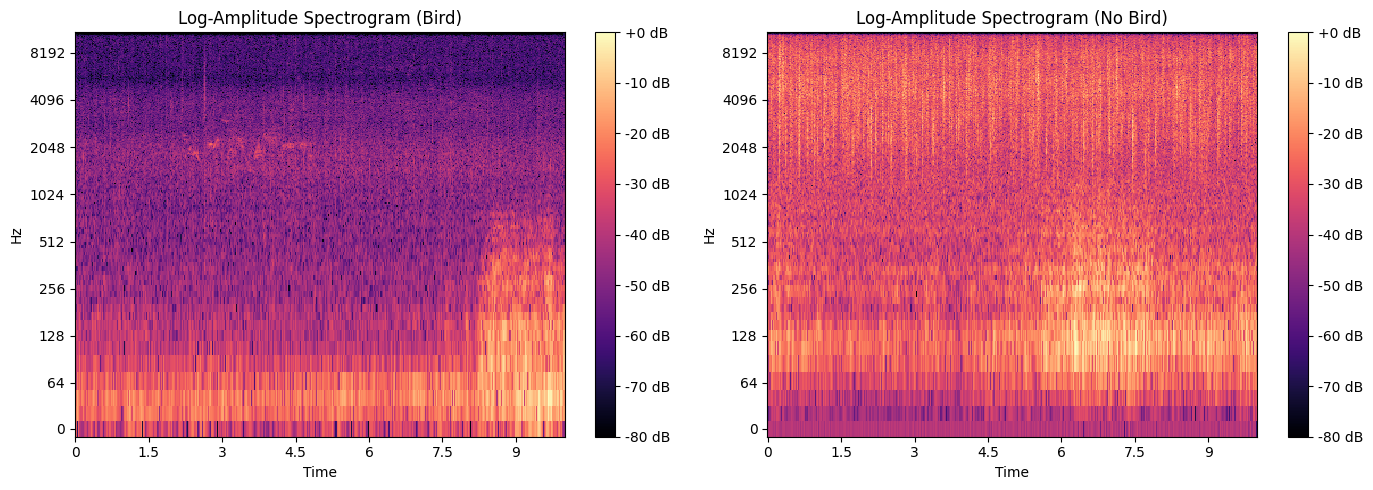

In [24]:
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
librosa.display.specshow(S_db_bird, sr=sr_bird, x_axis='time', y_axis='log')
plt.colorbar(format='%+2.0f dB')
plt.title('Log-Amplitude Spectrogram (Bird)')

plt.subplot(1, 2, 2)
librosa.display.specshow(S_db_no_bird, sr=sr_no_bird, x_axis='time', y_axis='log')
plt.colorbar(format='%+2.0f dB')
plt.title('Log-Amplitude Spectrogram (No Bird)')

plt.tight_layout()
plt.show()

5.3 Log-log Spectrogram:

- Use the "librosa.feature.melspectrogram" to calculate the mel spectrogram
- Convert the Mel Spectrogram to Log-Mel Spectrogram using the "librosa.power_to_db" function
- show the plot

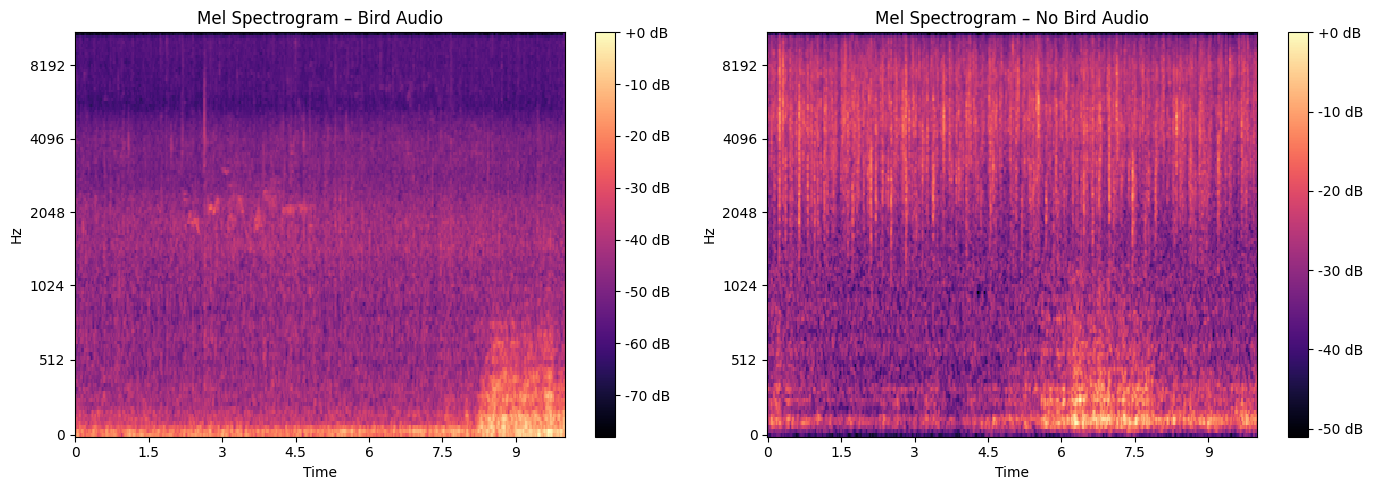

In [25]:
# Compute Mel Spectrograms
S_mel_bird = librosa.feature.melspectrogram(y=y_bird, sr=sr_bird, n_fft=2048, hop_length=HOP_LENGTH, n_mels=128)
S_mel_no_bird = librosa.feature.melspectrogram(y=y_no_bird, sr=sr_no_bird, n_fft=2048, hop_length=HOP_LENGTH, n_mels=128)

# Convert to dB scale
S_mel_db_bird = librosa.power_to_db(S_mel_bird, ref=np.max)
S_mel_db_no_bird = librosa.power_to_db(S_mel_no_bird, ref=np.max)

# Step 3: Plot Mel Spectrograms
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
librosa.display.specshow(S_mel_db_bird, sr=sr_bird, hop_length=512, x_axis='time', y_axis='mel')
plt.colorbar(format='%+2.0f dB')
plt.title('Mel Spectrogram – Bird Audio')

plt.subplot(1, 2, 2)
librosa.display.specshow(S_mel_db_no_bird, sr=sr_no_bird, hop_length=512, x_axis='time', y_axis='mel')
plt.colorbar(format='%+2.0f dB')
plt.title('Mel Spectrogram – No Bird Audio')

plt.tight_layout()
plt.show()

5.5 MFCC:

- Use the "librosa.feature.mfcc" to calculate the MFCC
- show the plot

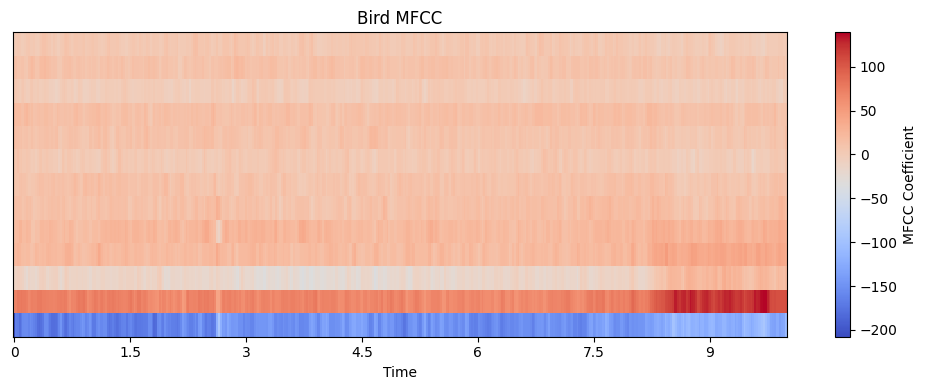

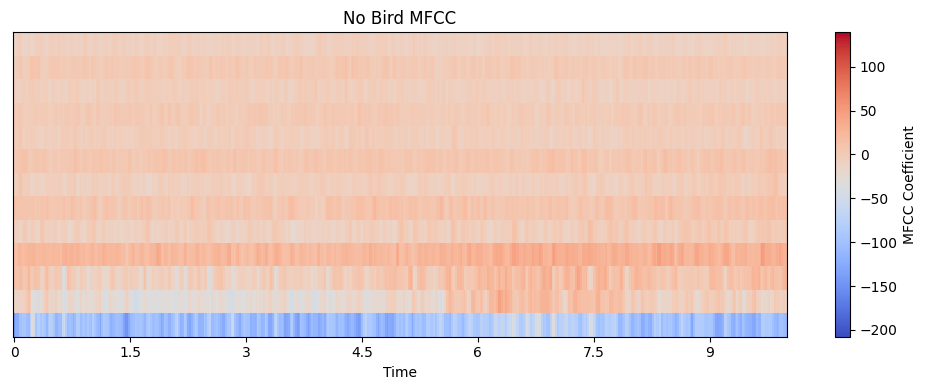

In [26]:
mfcc_bird = librosa.feature.mfcc(y=y_bird, sr=sr_bird, n_mfcc=13)
mfcc_no = librosa.feature.mfcc(y=y_no_bird, sr=sr_no_bird, n_mfcc=13)

vmin = min(np.min(mfcc_bird), np.min(mfcc_no))
vmax = max(np.max(mfcc_bird), np.max(mfcc_no))

# Plot Bird MFCC
plt.figure(figsize=(10, 4))
librosa.display.specshow(mfcc_bird, x_axis='time', sr=sr_bird, vmin=vmin, vmax=vmax)
plt.title('Bird MFCC')
plt.colorbar(label='MFCC Coefficient')
plt.tight_layout()
plt.show()

# Plot No Bird MFCC
plt.figure(figsize=(10, 4))
librosa.display.specshow(mfcc_no, x_axis='time', sr=sr_no_bird, vmin=vmin, vmax=vmax)
plt.title('No Bird MFCC')
plt.colorbar(label='MFCC Coefficient')
plt.tight_layout()
plt.show()

## 6. Conclusion
Which features are most different? Which ones may help classification?



## 7. Classification with SVM and Random Forest

- Create a function to obtain the import features and apply it to all the audio files.
- Split 30/70 train/test
- Check balanced
- Create two models and compare them (RF, SVM) using confusion matrix and other metrics
- Check features are important

Note, all the labels are here: ff1010bird_metadata_2018.csv


In [27]:
#Import libraries
import os
import pandas as pd
import librosa
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns


In [28]:
#Load label
label = pd.read_csv("/content/drive/MyDrive/ff1010bird/ff1010bird_metadata_2018.csv")
label_dict = dict(zip(label['itemid'], label['hasbird']))

label.head()


,itemid,datasetid,hasbird
0,64486,ff1010bird,0
1,2525,ff1010bird,0
2,44981,ff1010bird,0
3,101323,ff1010bird,0
4,165746,ff1010bird,0


In [29]:
#function to extract the features
def extract_features(file_path):
    y, sr = librosa.load(file_path, sr=None)
    y, _ = librosa.effects.trim(y)
    y = librosa.util.normalize(y)
    y = librosa.resample(y, orig_sr=sr, target_sr=22050)
    sr = 22050

    FRAME_SIZE = 1024
    HOP_LENGTH = 512

    mfcc = np.mean(librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13), axis=1)
    zcr = np.mean(librosa.feature.zero_crossing_rate(y, frame_length=FRAME_SIZE, hop_length=HOP_LENGTH))
    rms = np.mean(librosa.feature.rms(y=y, frame_length=FRAME_SIZE, hop_length=HOP_LENGTH))
    envelope = np.max(np.abs(y))
    centroid = np.mean(librosa.feature.spectral_centroid(y=y, sr=sr))
    bandwith=np.mean(librosa.feature.spectral_bandwidth(y=y, sr=sr))
    return np.hstack([mfcc, zcr, rms, envelope, centroid,bandwith])


In [30]:
from tqdm import tqdm

X, y = [], []

folder_path="/content/drive/MyDrive/ff1010bird/"

wav_files = [file for file in os.listdir(folder_path) if file.endswith(".wav")]


for file in tqdm(wav_files, desc="Processing audio files"):
    itemid = file.split("_")[-1].replace(".wav", "")
    label = label_dict[float(itemid)]

    file_path = os.path.join(folder_path, file)
    features = extract_features(file_path)
    X.append(features)
    y.append(label)

X = np.array(X)
y = np.array(y)
print (X.shape, y.shape)

Processing audio files: 100%|██████████| 7690/7690 [20:57<00:00,  6.12it/s]

(7690, 18) (7690,)


In [45]:
classes, counts = np.unique(y, return_counts=True)
for c, count in zip(classes, counts):
    print(f"Label {c}: {count} samples")

Label 0: 5755 samples
Label 1: 1935 samples


In [46]:
# Train/test split
from sklearn.model_selection import train_test_split
#Use stratify because the data are unbalanced
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2, random_state=42)

In [47]:
# Train classifiers
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)
svm = SVC(random_state=42)
svm.fit(X_train, y_train)

SVC(random_state=42)

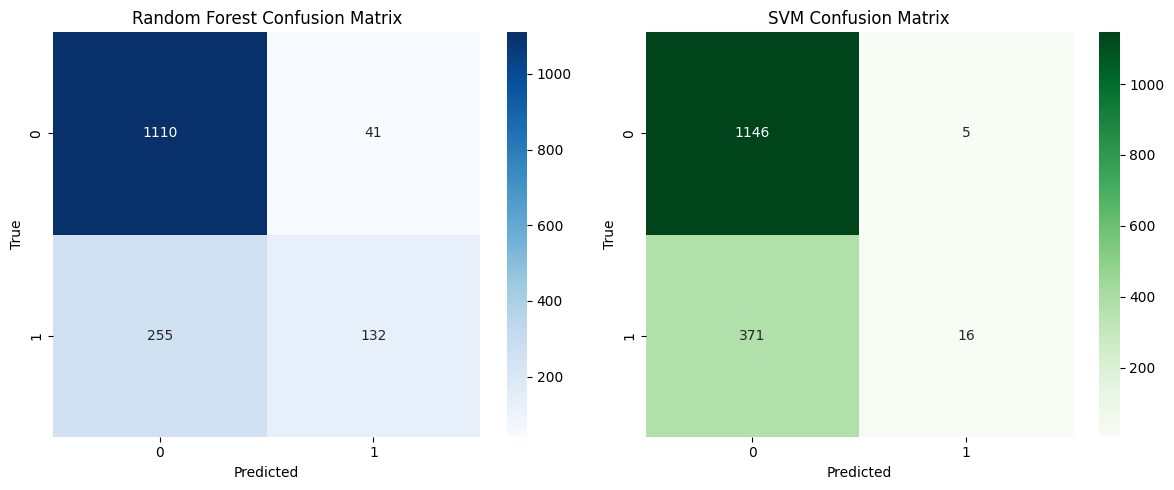

In [49]:
# Predictions
y_pred_rf = rf.predict(X_test)
y_pred_svm = svm.predict(X_test)

# Evaluation
rf_report = classification_report(y_test, y_pred_rf, output_dict=True)
svm_report = classification_report(y_test, y_pred_svm, output_dict=True)

rf_cm = confusion_matrix(y_test, y_pred_rf)
svm_cm = confusion_matrix(y_test, y_pred_svm)


# Plot confusion matrices
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.heatmap(rf_cm, annot=True, fmt="d", cmap="Blues")
plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")

plt.subplot(1, 2, 2)
sns.heatmap(svm_cm, annot=True, fmt="d", cmap="Greens")
plt.title("SVM Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")

plt.tight_layout()
plt.show()

In [51]:
rf_report_df = pd.DataFrame(rf_report).transpose()
svm_report_df = pd.DataFrame(svm_report).transpose()

In [52]:
rf_report_df

,precision,recall,f1-score,support
0,0.813187,0.964379,0.882353,1151.000000
1,0.763006,0.341085,0.471429,387.000000
accuracy,0.807542,0.807542,0.807542,0.807542
macro avg,0.788096,0.652732,0.676891,1538.000000
weighted avg,0.800560,0.807542,0.778954,1538.000000


In [53]:
svm_report_df

,precision,recall,f1-score,support
0,0.755438,0.995656,0.859070,1151.000000
1,0.761905,0.041344,0.078431,387.000000
accuracy,0.755527,0.755527,0.755527,0.755527
macro avg,0.758672,0.518500,0.468751,1538.000000
weighted avg,0.757065,0.755527,0.662642,1538.000000


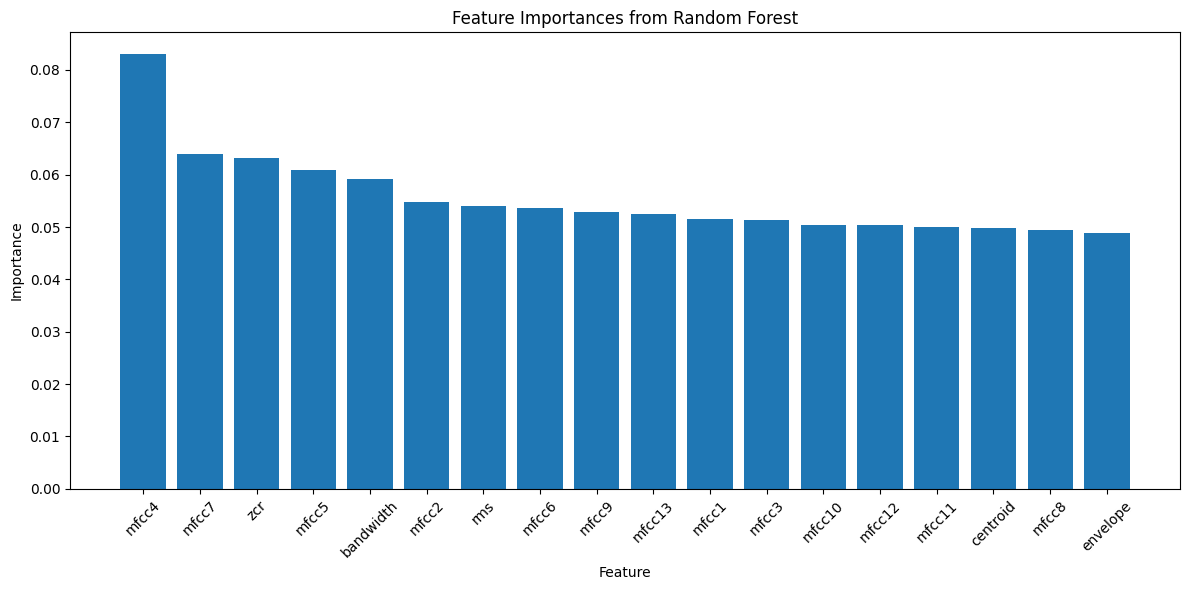

In [55]:
feature_names = [
    'mfcc1', 'mfcc2', 'mfcc3', 'mfcc4', 'mfcc5', 'mfcc6', 'mfcc7',
    'mfcc8', 'mfcc9', 'mfcc10', 'mfcc11', 'mfcc12', 'mfcc13',
    'zcr', 'rms', 'envelope', 'centroid', 'bandwidth'
]

importances = rf.feature_importances_
indices = np.argsort(importances)[::-1]  # Sort in descending order

plt.figure(figsize=(12, 6))
plt.bar(range(len(importances)), importances[indices], align="center")
plt.xticks(range(len(importances)), np.array(feature_names)[indices], rotation=45)
plt.xlabel("Feature")
plt.ylabel("Importance")
plt.title("Feature Importances from Random Forest")
plt.tight_layout()
plt.show()


